In [1]:
import numpy as np
import cv2 as cv
import imageio
import matplotlib.pyplot as plt
import gdown
import os
import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision.transforms.functional import rgb_to_grayscale
from torchnlp.encoders import LabelEncoder 
from torcheval.metrics.functional import word_error_rate
print("packages imported successfully!")


packages imported successfully!


In [2]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]
device


device(type='cuda')

In [4]:
"""data_url = "https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL"
data_out = "data.zip"
gdown.download(data_url, data_out, quiet = False)
gdown.extractall("data.zip")"""

'data_url = "https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL"\ndata_out = "data.zip"\ngdown.download(data_url, data_out, quiet = False)\ngdown.extractall("data.zip")'

Data preprocessing 

In [5]:
path = "data/s1"

def get_filenames(path):
    for _, _, file in os.walk(path):
        files = file

    return [file.split(".")[0].encode("utf-8") for file in files] 

In [6]:
def get_split_files(path, train_size = 0.9, split = "train"):
    filenames = get_filenames(path)
    training_len = int(train_size * len(filenames))
    if split == "train":
        return filenames[0 : training_len]
    else : 
        return filenames[training_len : ]

In [7]:
filenames = get_filenames(path)
training_files = get_split_files(path)
val_files = get_split_files(path, split="val")

In [8]:
def capture_frames(video_path):
    capture = cv.VideoCapture(video_path)
    frames = []
    number_of_frames = int(capture.get(cv.CAP_PROP_FRAME_COUNT))
    for _ in range(number_of_frames):
        ret, frame = capture.read()
        frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        frames.append(frame[190 : 236, 100 : 200])
    capture.release()
    return np.array(frames)
    
def reduce_frames(frames):
    mean = np.mean(frames)
    std = np.std(frames)
    return torch.from_numpy((frames - mean) / std)

def get_video_path(filename) : 
    filename = filename.decode("utf-8")
    return os.path.join(path, f"{filename}.mpg")
    

def load_video(filename):
    video_path = get_video_path(filename)
    frames = capture_frames(video_path)
    return reduce_frames(frames)
    
    
def get_annotation_path(filename) : 
    filename = filename.decode("utf-8")
    return os.path.join("data", "align\s1", f"{filename}.align")

def split_line(annotation_path):
    with open(annotation_path, 'r') as f:
        lines = f.readlines()
    token = []
    for line in lines:
        words = line.split()
        if words[2] != "sil":
            token = [*token, " ", words[2]]
    return token


def split_words(line):
    tokens = []
    for word in line:
        for character in word:
            tokens.append(character)
    return tokens
    

def load_annot(filename) : 
    annotation_path = get_annotation_path(filename)
    line_split = split_line(annotation_path)
    tokens = split_words(line_split)
    return encode(tokens)


def encode(data):
    encoder = LabelEncoder(vocab, reserved_labels=['...'], unknown_index=-1)
    return encoder.batch_encode(data)

def decode(data):
    encoder = LabelEncoder(vocab, reserved_labels=['...'], unknown_index=-1)
    return encoder.batch_decode(data)

In [9]:
class LipDataset(Dataset):
    def __init__(self, path, split, train_size = 0.9):
        super(LipDataset, self).__init__()
        self.filenames = get_split_files(path, train_size=train_size, split=split)
    def __len__(self):
        return len(self.filenames)
    def __getitem__(self, idx):
        filename = self.filenames[idx]
        frames  = load_video(filename).float()
        annot = load_annot(filename).float()
        frames = frames.unsqueeze(0)
        frames = frames.permute(1, 2, 3, 0)
        return (frames, annot.to(torch.long))

In [10]:
training_data = LipDataset(path, "train")
frame, annot = training_data[0]


In [11]:
frame.size()

torch.Size([75, 46, 100, 1])

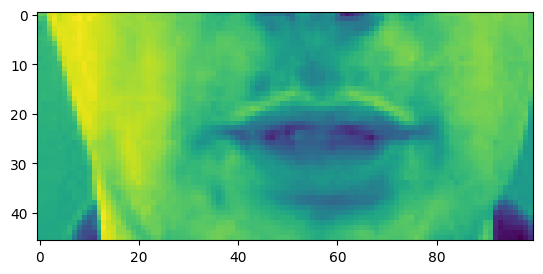

In [15]:
plt.imshow(frame[35]) 

In [17]:
import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn

def collate_fn(batch):
    """
    Custom collate function to pad sequences in a batch dynamically to the 
    maximum sequence length in the batch for both data and labels.
    
    Args:
        batch: List of tuples (data, label) where `data` and `label` are tensors.

    Returns:
        Tuple of padded data and padded labels.
    """
    # Unzip the batch into separate data and label lists
    batch_data, batch_labels = zip(*batch)

    # Dynamically determine the maximum label length in the batch
    max_label_length = max(label.shape[0] for label in batch_labels)

    # Pad input data sequences
    padded_data = pad_sequence(batch_data, batch_first=True, padding_value=0)  # Pad with 0 for data

    # Pad label sequences to max_label_length
    padded_labels = pad_sequence(
        batch_labels, batch_first=True, padding_value=-1  # Pad with -1 for labels
    )

    return padded_data, padded_labels


In [ ]:
batch_size = 1
training_loader = DataLoader(training_data, batch_size=batch_size, collate_fn = collate_fn)

In [19]:
val_data = LipDataset(path, split = "val")
val_loader = DataLoader(val_data, batch_size=batch_size, collate_fn = collate_fn)

Data pipeline 

In [20]:
data, labels = next(iter(training_loader))

print(data)

tensor([[[[[ 1.2087],
           [ 0.6399],
           [ 1.1707],
           ...,
           [ 1.0191],
           [ 1.0191],
           [ 1.0191]],

          [[ 1.2087],
           [ 0.5261],
           [ 1.0949],
           ...,
           [ 1.0191],
           [ 1.0191],
           [ 1.0191]],

          [[ 1.2845],
           [ 0.9432],
           [ 1.1707],
           ...,
           [ 1.0191],
           [ 1.0191],
           [ 1.0191]],

          ...,

          [[-0.4218],
           [-0.4218],
           [-0.4218],
           ...,
           [-3.3416],
           [-3.3795],
           [-2.8107]],

          [[-0.4218],
           [-0.4218],
           [-0.4218],
           ...,
           [-3.6449],
           [-3.5312],
           [-3.2657]],

          [[-0.4218],
           [-0.4218],
           [-0.4218],
           ...,
           [-3.7966],
           [-3.5691],
           [-3.6449]]],


         [[[ 0.9812],
           [ 0.6778],
           [ 1.2466],
           ...,


In [21]:
decode(labels[0])

[' ',
 'b',
 'i',
 'n',
 ' ',
 'b',
 'l',
 'u',
 'e',
 ' ',
 'a',
 't',
 ' ',
 'f',
 ' ',
 't',
 'w',
 'o',
 ' ',
 'n',
 'o',
 'w']

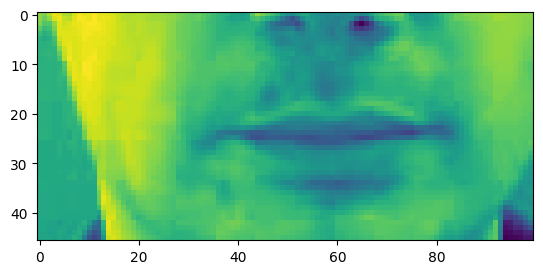

In [22]:
plt.imshow(data[0][72])

Model design 

In [23]:
Baselines =""" {
    AvgHearingImpearedPerson : [OverlappingSpeaker = (CER = , WER = ), UnseenSpeaker = (CER = , WER = 0.47)],
    BaselineLSTM : [OverlappingSpeaker = (CER = 15.2, WER = 26.3), UnseenSpeaker = (CER = 38.4, WER = 52.8)],
    Baseline-2D : [OverlappingSpeaker = (CER = 4.3, WER = 11.6), UnseenSpeaker = (CER = 16.2, WER = 26.7)],
    Baseline-NoLM : [OverlappingSpeaker = (CER = 2.0, WER = 5.6), UnseenSpeaker = (CER = 6.7, WER = 13.6)],
    LipNet : [OverlappingSpeaker = (CER = 1.9, WER = 4.8), UnseenSpeaker = (CER = 6.4, WER = 11.4)]
}"""

In [24]:
class LipNet(nn.Module):

    def __init__(self):
        super(LipNet, self).__init__()
        self.conv1 = nn.Conv3d(in_channels= 1, out_channels= 32, kernel_size= (3, 5, 5), bias=False)
        self.pool1 = nn.MaxPool3d(kernel_size= (1, 2, 2), stride=(1, 2, 2))
        self.conv2 = nn.Conv3d(in_channels= 32, out_channels= 64, kernel_size= (3, 5, 5), bias=False)
        self.pool2 = nn.MaxPool3d(kernel_size= (1, 2, 2), stride=(1, 2, 2))
        self.conv3 = nn.Conv3d(in_channels= 64, out_channels= 96, kernel_size= (3, 3, 3),  bias=False)
        self.pool3 = nn.MaxPool3d(kernel_size= (1, 2, 2), stride=(1, 2, 2))
        self.gru1 = nn.GRU(input_size = 96 * 3 * 10,hidden_size =256, bidirectional=True, batch_first=True)
        self.layer_norm1 = nn.LayerNorm(512)
        self.gru2 = nn.GRU(input_size = 512,hidden_size =256, bidirectional=True, batch_first=True)
        self.layer_norm2 = nn.LayerNorm(512)
        self.dense = nn.Linear(in_features=512, out_features=41)

    def forward(self, x):
        #Shape of x is B, D, H, W, C
        #if torch.isnan(x).any():
            #print("Input contains nan")
        x = x.permute(0, 4, 1, 2, 3)
        x = self.conv1(x)
        #if torch.isnan(x).any():
            #print("After conv1 contains nan")
        x = F.relu(x)
        #if torch.isnan(x).any():
            #print("After relu1 contains nan")
        x = self.pool1(x)
        
        x = F.relu(x)
        
      
        x = F.relu(self.conv2(x))
     
        x = F.relu(self.pool2(x))
        
       
        x = self.conv3(x)
      
        x = F.relu(x)
       
        x = F.relu(self.pool3(x))
        

        b, c, d, h, w = x.size() # Batch, Channels, D, H, W
        x = x.permute(0, 2, 1, 3, 4)
        x = x.contiguous().view(b, d, -1) # X shape is (B, D, Channels * H * W)

        x, hidden = self.gru1(x)
    
        x = self.layer_norm1(x)
        
        x = F.relu(x)
    
        x, hidden = self.gru2(x)
      
        x = self.layer_norm2(x)
   
        x = F.relu(x)
   


        x = self.dense(x) 
        return x

In [25]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.conv = nn.Conv3d(in_channels= 1, out_channels= 1, kernel_size= (5, 17, 21), bias=False)
        self.pool1 = nn.MaxPool3d(kernel_size= (10, 2, 5), stride=(1, 2, 5))
        #self.gru1 = nn.GRU(input_size = 15 * 16 , hidden_size =256, bidirectional=True, batch_first=True)
        #self.layer_norm1 = nn.LayerNorm(512)
        self.dense = nn.Linear(in_features=15*16, out_features=40)
        
    def forward(self, x):
        x = x.permute(0, 4, 1, 2, 3)
        x = F.relu(self.pool1(F.relu(self.conv(x))))
        b, c, d, h, w = x.size() # Batch, Channels, D, H, W
        x = x.permute(0, 2, 1, 3, 4)
        x = x.contiguous().view(b, d, -1)
       # x, _ = self.gru1(x)
        #x = F.relu(self.layer_norm1(x))
        return self.dense(x)



In [26]:
model = LipNet()
_, data = next(enumerate(training_loader))
frames, labels = data
print(frames.shape)
B, D, H, W, C = frames.shape
out = model(frames)
out.size()  # Batch, Time, Classes

torch.Size([1, 75, 46, 100, 1])


torch.Size([1, 69, 41])

In [27]:
def initialize_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
    if isinstance(m, nn.GRU):
        for name, param in m.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)


In [28]:
"""loss_fn = nn.CTCLoss(blank=0, reduction= "sum", zero_infinity= True)
model = SimpleModel()
model = model.to(device)
model.apply(initialize_weights)

optimizer = torch.optim.SGD(model.parameters(), lr=5e-4)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=2)

def train_one_epoch(optimizer):
    model.train(True)
    running_loss = 0
    epoch_loss = 0
    

    for i, data in enumerate(training_loader):
        frames, labels = data
        frames, labels = frames.to(device), labels.to(device)

        tokens = model(frames)


        B, target_D = labels.size()
        B, D, C = tokens.size()
        tokens = tokens.permute(1, 0, 2) # shape D, B, C
        tokens = F.log_softmax(tokens, dim = 2)
        input_lengths = torch.full((B,), D, dtype=torch.long)
        target_lengths = torch.full((B,), target_D, dtype=torch.long)
        assert(f"input lenghts is greater than the output length {input_lengths > target_lengths}")
        loss = loss_fn(tokens, labels, input_lengths, target_lengths)
        running_loss += loss.item()
        epoch_loss += loss.item()
        optimizer.zero_grad()  # Clear accumulated gradients
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()  # Update model weights
        
    epoch_loss = epoch_loss / (i + 1)
  
            
        
    return epoch_loss


epoch_number = 0
history = {"train" : [], "val" : [], "epochs" : []}
best_v_loss = 10000
EPOCHS = 15



for epoch in range(EPOCHS):
    #Training phase
    print('EPOCH {}:'.format(epoch_number + 1))
    avg_loss = train_one_epoch(optimizer)
    history['train'].append(avg_loss)
    #scheduler.step(avg_loss)
    

    #Val phase
    model.eval()
    running_vloss = 0
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
                vframes, vlabels = vdata
                vframes, vlabels = vframes.to(device), vlabels.to(device)
                vout = model(vframes)
                B, target_D = vlabels.size()
                B, D, C = vout.size()
                vout = vout.permute(1, 0, 2) # shape D, B, C
                vout = F.log_softmax(vout, dim = 2)
                vinput_lengths = torch.full((B,), D, dtype=torch.long)
                vtarget_lengths = torch.full((B,), target_D, dtype=torch.long)
                vloss = loss_fn(vout, vlabels, vinput_lengths, vtarget_lengths).item()
                running_vloss += vloss
    avg_vloss = running_vloss / (i + 1)
    
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))
    history['val'].append(avg_vloss)

    #Update epoch number
    epoch_number += 1
    history['epochs'].append(epoch_number)
    
"""

'loss_fn = nn.CTCLoss(blank=0, reduction= "sum", zero_infinity= True)\nmodel = SimpleModel()\nmodel = model.to(device)\nmodel.apply(initialize_weights)\n\noptimizer = torch.optim.SGD(model.parameters(), lr=5e-4)\n#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode=\'min\', factor=0.8, patience=2)\n\ndef train_one_epoch(optimizer):\n    model.train(True)\n    running_loss = 0\n    epoch_loss = 0\n    \n\n    for i, data in enumerate(training_loader):\n        frames, labels = data\n        frames, labels = frames.to(device), labels.to(device)\n\n        tokens = model(frames)\n\n\n        B, target_D = labels.size()\n        B, D, C = tokens.size()\n        tokens = tokens.permute(1, 0, 2) # shape D, B, C\n        tokens = F.log_softmax(tokens, dim = 2)\n        input_lengths = torch.full((B,), D, dtype=torch.long)\n        target_lengths = torch.full((B,), target_D, dtype=torch.long)\n        assert(f"input lenghts is greater than the output length {input_lengths > 

In [29]:
def plot_loss_acc(history):
    fig, axs = plt.subplots(1, 2, sharex = True)
    x_axis = history["epochs"]
    axs[0].plot(x_axis, history["train"])
    axs[0].set_title(f'train loss per epoch')
    axs[1].plot(x_axis, history["val"])
    axs[1].set_title(f'validation loss per epoch')
    plt.show()

In [ ]:
#TO DO :
    # CTC DECODER : Done 
    # ADD DROPOUT LAYERS AND REGULARIZATION TO AVOID OVERFITTING
    # LENGTHEN INPUT SEQUENCE TO IMPROVE MODEL (START WITH 75)
    # REPLACE GRU WITH ATTENTION MODULE

In [36]:
def ctc_decode(encoded_sequence, blank=0, max_iter=4):
    decoded_sequence = []
    prev_token = blank
    iter = 0
 
    for token in encoded_sequence:
        if (token!= prev_token and token != blank) or iter > max_iter:
            prev_token = token
            decoded_sequence.append(token)
            iter = 0
        if token == prev_token:
            iter += 1
    
    return torch.tensor(decoded_sequence)
            


In [46]:
class AttentionModel(nn.Module):
    def __init__(self):
        super(AttentionModel, self).__init__()
        self.conv1 = nn.Conv3d(in_channels= 1, out_channels= 32, kernel_size= (1, 5, 5), bias=False)
        self.pool1 = nn.MaxPool3d(kernel_size= (1, 2, 2), stride=(1, 2, 2))
        self.conv2 = nn.Conv3d(in_channels= 32, out_channels= 64, kernel_size= (1, 5, 5), bias=False)
        self.pool2 = nn.MaxPool3d(kernel_size= (1, 2, 2), stride=(1, 2, 2))
        self.conv3 = nn.Conv3d(in_channels= 64, out_channels= 96, kernel_size= (1, 3, 3),  bias=False)
        self.pool3 = nn.MaxPool3d(kernel_size= (1, 2, 2), stride=(1, 2, 2))

        self.flatten = nn.Flatten(start_dim=2)

        self.attention_layers = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=2880, 
                nhead=8, 
                dim_feedforward=512,
                batch_first=True,
                dropout= 0.25
            ), 
            num_layers=2
        )

        self.dense = nn.Linear(in_features=2880, out_features=41)


    def forward(self, x):
        x = x.permute(0, 4, 1, 2, 3)
        
        # Convolutional layers
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.pool3(x)  # [1, 96, 75, 3, 10]
        
        # Flatten and permute for attention layers
        x = x.permute(0, 2, 1, 3, 4)
        
        x = self.flatten(x)  # Shape: (batch_size, seq_len, feature_dim)
        # Shape: (batch_size, seq_len, feature_dim)
        

        # Attention layer 1
        x = self.attention_layers(x)
      

        # Final dense layer
        x = self.dense(x)

        return x 


In [48]:
def train_for_one_epoch(model, optimizer, loss_fn):
    model.train()
    epoch_loss = 0
    for i, data in enumerate(training_loader):
        frames, labels = data
        frames, labels = frames.to(device), labels.to(device)

        tokens = model(frames)


        B, target_D = labels.size()
        B, D, C = tokens.size()
        tokens = tokens.permute(1, 0, 2) # shape D, B, C
        tokens = F.log_softmax(tokens, dim = 2)

        input_lengths = torch.full((B,), D, dtype=torch.long)
        target_lengths = torch.full((B,), target_D, dtype=torch.long)
        assert(f"input lenghts is greater than the output length {input_lengths > target_lengths}")
        loss = loss_fn(tokens, labels, input_lengths, target_lengths)
        epoch_loss += loss.item()

        optimizer.zero_grad()  # Clear accumulated gradients
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()  # Update model weights
        
    return epoch_loss / (i + 1)

def predict(model, x) : 
     return torch.argmax(model(x), axis = 2)

def validate_model(model, loss_fn):
    model.eval()
    running_vloss = 0
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
                vframes, vlabels = vdata
                vframes, vlabels = vframes.to(device), vlabels.to(device)
                vout = model(vframes)

                B, target_D = vlabels.size()
                B, D, C = vout.size()
                vout = vout.permute(1, 0, 2) # shape D, B, C
                vout = F.log_softmax(vout, dim = 2)
                vinput_lengths = torch.full((B,), D, dtype=torch.long)
                vtarget_lengths = torch.full((B,), target_D, dtype=torch.long)

                vloss = loss_fn(vout, vlabels, vinput_lengths, vtarget_lengths).item()
                running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    return avg_vloss, vout 

def train(model, optimizer, loss_fn, n_epochs, scheduler):
     history = {"epochs" : [], "traing_loss": [], "val_loss": []}
     best_models = {"epoch" : [], "loss" : [], "predictions" : []}
     best_v_loss = 1000
     for epoch in range(n_epochs):
        avg_loss = train_for_one_epoch(model, optimizer, loss_fn)
        avg_vloss, last_pred = validate_model(model, loss_fn)
        scheduler.step(avg_vloss)

        history["epochs"].append(epoch +1)
        history["traing_loss"].append(avg_loss)
        history["val_loss"].append(avg_vloss)

        print(f"EPOCH {epoch+1} : training loss : {avg_loss}, validation loss : {avg_vloss}")

        if avg_vloss < best_v_loss :
            best_v_loss = avg_vloss
            best_models["epoch"].append(epoch + 1)
            best_models["loss"].append(avg_vloss)
            best_models["predictions"].append(ctc_decode(torch.argmax(last_pred, axis = 2)))

        if (epoch + 1) % 25 ==0:
             torch.save(model, f"LipAttention_EPOCH_{epoch+1}.pt")
               

     return history, best_models

In [ ]:
torch.cuda.empty_cache()


loss_fn = nn.CTCLoss(blank=0, reduction="sum", zero_infinity=True)
model = AttentionModel()
model = model.to(device)
model.apply(initialize_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=2)
history, best_models = train(model, optimizer, loss_fn, 160, scheduler)


    
